In [5]:
import pandas as pd
import numpy as np
import joblib
import shap
from sklearn.model_selection import train_test_split

# 1. Load the actual processed file you generated in Task 1
df_final = pd.read_csv('../data/processed/fraud_features_final.csv')

# 2. Isolate features and target variable
X = df_final.drop(columns=['class'])
y = df_final['class']

# 3. Perform a Stratified Train/Test split matching your modeling parameters
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Take a lightweight sample so SHAP runs fast
X_test_sample = X_test.sample(n=1000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]  # FIXED: Changed .iloc to .loc!

# 5. Load your model and compute SHAP values
model = joblib.load('../models/best_ecommerce_xgb.pkl')
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_sample)

print("SHAP values calculated successfully! You are ready to plot.")

SHAP values calculated successfully! You are ready to plot.


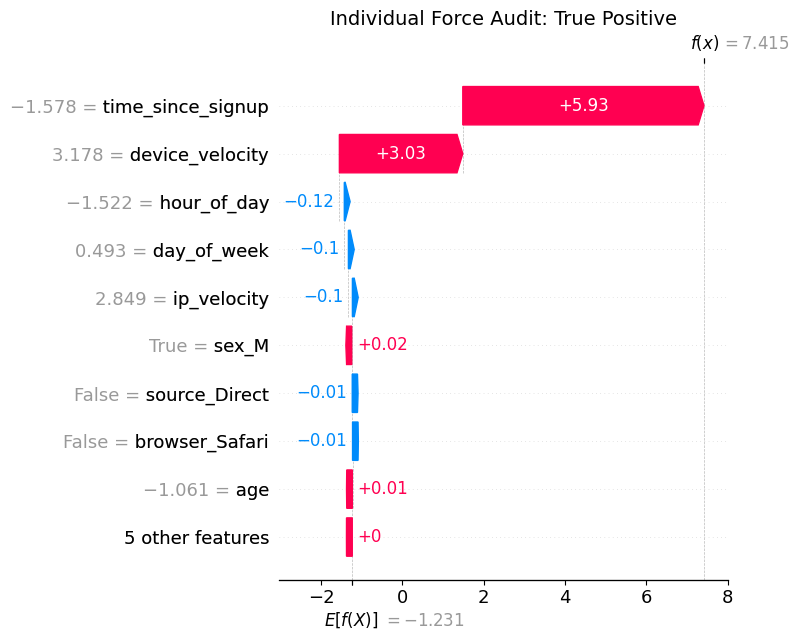

No samples found matching classification criteria for: False_Positive


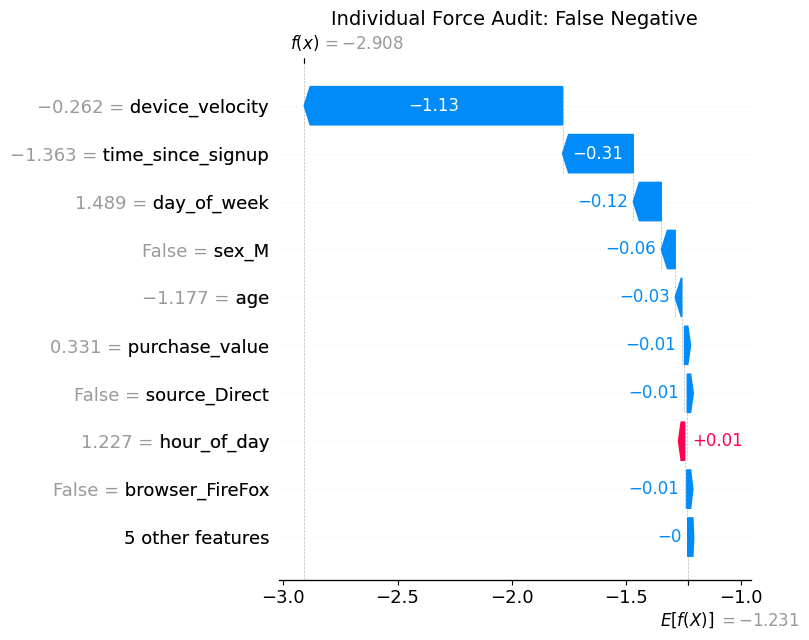

In [7]:
# Predict on the sampled test data
y_preds_sample = model.predict(X_test_sample)

# Reset indices or use .values to keep lookups purely relative to the 1000 rows
y_test_sample_vals = y_test_sample.values.flatten()

# Find relative indices (0 to 999) inside this 1000-row sample frame
true_positives = np.where((y_preds_sample == 1) & (y_test_sample_vals == 1))[0]
false_positives = np.where((y_preds_sample == 1) & (y_test_sample_vals == 0))[0]
false_negatives = np.where((y_preds_sample == 0) & (y_test_sample_vals == 1))[0]

# Generate and save waterfall plots smoothly
for name, indices in [("True_Positive", true_positives), 
                      ("False_Positive", false_positives), 
                      ("False_Negative", false_negatives)]:
    if len(indices) > 0:
        idx = int(indices[0]) # Target the first relative row index (e.g., 0 to 999)
        plt.figure(figsize=(12, 4))
        
        # Access the relative index position of the 1000 SHAP calculations
        shap.plots.waterfall(shap_values[idx], show=False)
        
        plt.title(f"Individual Force Audit: {name.replace('_', ' ')}", fontsize=14)
        plt.tight_layout()
        plt.savefig(f'../notebooks/shap_{name.lower()}.png')
        plt.show()
    else:
        print(f"No samples found matching classification criteria for: {name}")